# IS 4487 Assignment 14: Exploring APIs with yfinance

In this assignment, you will:
- Choose an industry you're interested in (such as tech, airlines, or retail)
- Use the `yfinance` Python package as an API to collect historical stock price data
- Clean and prepare the data for analysis
- Explore trends, volatility, and relationships between companies
- Summarize your findings and recommendation in a business memo

## Why This Matters

APIs (Application Programming Interfaces) allow businesses to pull live, real-world data from external sources directly into their analytics tools. Financial analysts, investment firms, and business leaders use APIs like `yfinance` to monitor company performance, assess market trends, and build models based on dynamic data.

This assignment helps you gain hands-on experience with one of the most common API workflows in business analytics: fetching, cleaning, analyzing, and interpreting financial data to support better decision-making.

<a href="https://colab.research.google.com/github/Stan-Pugsley/is_4487_base/blob/main/Assignments/assignment_14_api.ipynb" target="_parent">
  <img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/>
</a>



## Step 1: Choose an Industry and Find Company Ticker Symbols

Visit the following website to explore U.S. stock sectors and industries:  
https://www.tradingview.com/markets/stocks-usa/sectorandindustry-sector/

Choose one industry you are interested in (for example: Airlines, Technology, Fast Food, Retail, Energy, etc.).  
Write the names and ticker symbols of 4 public companies in that industry.

**Example:**
- Industry: Technology  
- Tickers: AAPL, MSFT


In [9]:
# Replace this list with your selected tickers
tickers = ['NVDA', 'AAPL', 'AVGO', 'TSM']

## Step 2: Use yfinance to Collect Historical Stock Data

Follow the steps below to use the `yfinance` API to collect historical stock price data.

### Instructions

1. Make sure the `yfinance` package is installed by running the code cell below.
2. Import any additional Python libraries that you might need to explore or visualize the data.
3. Use the `yf.download()` function to pull **5 years of daily adjusted close prices** for the companies you selected in Step 1.
    - Choose a start date and an end date that span the past 5 years (e.g., `"2020-01-01"` to `"2025-12-31"`).
    - Only select the **'High'** column, which represents the daily high
4. Preview the first few rows of the dataset using `.head()` to confirm that the data has loaded correctly.



In [2]:
# 1. Import necessary libraries
!pip install yfinance

import yfinance as yf
import pandas as pd

In [14]:
# Download adjusted close prices
df = yf.download(tickers, start="2021-01-01", end="2026-01-01")['High']


/tmp/ipykernel_13782/1641020391.py:2: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(tickers, start="2021-01-01", end="2026-01-01")['High']
[*********************100%***********************]  4 of 4 completed


In [15]:
df.head()

Ticker,AAPL,AVGO,NVDA,TSM
Date,,,,
2021-01-04,129.941395,39.700949,13.613477,104.626547
2021-01-05,128.122724,38.547388,13.405075,105.405967
2021-01-06,127.451681,39.013311,13.207142,106.726391
2021-01-07,128.015768,39.911921,13.339514,112.732576
2021-01-08,128.988271,40.396695,13.382639,115.804429


## Step 3: Clean the Data

The data you pulled may contain missing values. Follow these steps:

1. Check the dataset for missing values using `.isnull().sum()`.
2. Fill any missing values using a forward fill method.
3. Recheck for missing values to confirm they have been handled.



In [18]:
# Add code here 🔧
# 1. Check for missing values
df.isnull().sum()

# 2. Fill missing values (forward fill)
df = df.fillna(method='ffill')

# 3. Check again
df.isnull().sum()

/tmp/ipykernel_13782/3706767255.py:6: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df = df.fillna(method='ffill')


,0
Ticker,
AAPL,0
AVGO,0
NVDA,0
TSM,0


## Step 4: Calculate Daily Returns

To better understand price movement, calculate the daily percentage change for each stock.

1. Use the `.pct_change()` method to calculate daily returns.
2. Drop any rows with missing values that may result from this calculation.
3. Preview the returns DataFrame to confirm it's correct.


In [19]:
# Add code here 🔧
# 1. Calculate daily returns
returns = df.pct_change()

# 2. Drop missing values
returns = returns.dropna()

# 3. Preview
returns.head()

Ticker,AAPL,AVGO,NVDA,TSM
Date,,,,
2021-01-05,-0.013996,-0.029056,-0.015309,0.007450
2021-01-06,-0.005238,0.012087,-0.014766,0.012527
2021-01-07,0.004426,0.023033,0.010023,0.056276
2021-01-08,0.007597,0.012146,0.003233,0.027249
2021-01-11,-0.018548,-0.002689,0.040236,-0.021300


## Step 5: Explore the Data Visually and Statistically

In this step, you will create visualizations and metrics to help understand stock behavior. Don’t interpret or explain anything here — just create the outputs so you can use them in your reflection later.

1. Create a line chart showing stock prices over the 5-year period.
2. Calculate the standard deviation of daily returns for each stock (volatility).
3. Create a correlation matrix of the daily returns between companies.




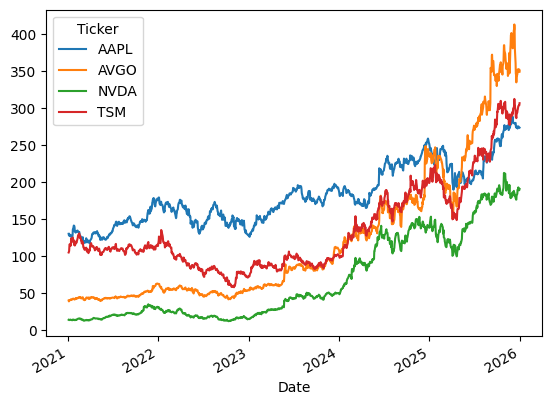

In [22]:
# Add code here 🔧
import matplotlib.pyplot as plt

# 1. Line chart of stock prices
df.plot()
plt.show()

In [23]:
# 2. Standard deviation (volatility)
returns.std()

,0
Ticker,
AAPL,0.015260
AVGO,0.024219
NVDA,0.029001
TSM,0.022396


In [24]:
# 3. Correlation matrix
returns.corr()

Ticker,AAPL,AVGO,NVDA,TSM
Ticker,,,,
AAPL,1.000000,0.349794,0.404044,0.389678
AVGO,0.349794,1.000000,0.554453,0.558357
NVDA,0.404044,0.554453,1.000000,0.624784
TSM,0.389678,0.558357,0.624784,1.000000


## Step 6: Write a Stakeholder Recommendation Memo

Now that you’ve completed your analysis, it’s time to turn your work into a clear, professional memo for a business audience.

### Scenario

You’ve been asked by a stakeholder (an investor, executive, or client) to evaluate whether it's a good time to invest in a particular industry. They’ve asked you to use recent stock performance data from several leading companies in that industry to help guide their decision.

### Your Task

Use the results from your code in Steps 2–5 to write a **multi-paragraph business memo** that:

1. **Introduces the industry you analyzed** and names the companies you included.
2. **Summarizes major trends** you observed in the stock prices over the last 5 years.
3. **Discusses key metrics**, such as volatility and correlations between companies.
4. **Presents your investment recommendation** — based on your evidence — and explains why you would or wouldn’t advise investing in this industry now.
5. **Suggests future analytics or data sources** that could strengthen or update your recommendation going forward.

This final section should show that you understand how real-world decisions evolve. Think about:
- What **additional data** might help (e.g., earnings reports, economic indicators, sentiment analysis)?
- What **types of models** could be applied (e.g., forecasting, classification, risk modeling)?
- How often should the analysis be updated?

### Format & Expectations

- Write **2–4 paragraphs** in business memo format (not bullet points).
- Use **specific, data-driven evidence** from your own analysis.
- Keep your writing professional and clear — imagine your reader is a client or executive, not a data analyst.
- Your memo should be written **entirely in your own words**. Do not copy from examples, online sources, or AI tools. Your writing should reflect your understanding and your interpretation of the results.
- You do not need to include charts in the memo — the code cells above already display them.



### Add memo here:

I have succesfully analyzed the technology industry using four major companies: Apple (AAPL), Broadcom (AVGO), NVIDIA (NVDA), and Taiwan Semiconductor (TSM). I have come to the conclusion that all of them (over the past 5 years) have an overall upward trend in stock prices, especially when looking at years 2023-2026. It is clear that NVIDIA and Broadcom has had the largets increase, whereas Apple and TSM are still steady and growing consistently. This showcases a strong demand in the industry, likely driven by advancements in areas like AI and semiconductor tech. Despite, some short-term fluctuations, the long-term trends is overall positive for all companies.

The key metircs I have identified also support this claim. For example, NVIDIA had the highest volatitlity of around 0.029 which shows a higher risk with larger price swings, where Apple had the lowest volatility at 0.015 which shows more stability. While it seems the stocks tend to move togehter, the correlation values of around 0.35 to 0.62 suggest they are not perfecly correlated. Overall based on this analysis, I would recommend investing in this industry, especially if investors are willing to face moderate risk for higher returns. Future analysis could be improved by adding additional data like earning reports or forecasting models that are reguraly updated to reflect changing market conditions.

## Submission Instructions
✅ Checklist:
- All code cells run without error
- All markdown responses are complete
- Submit on Canvas as instructed

In [8]:
!jupyter nbconvert --to html "assignment_14_api.ipynb"

[NbConvertApp] WARNING | pattern 'assignment_14_api.ipynb' matched no files
This application is used to convert notebook files (*.ipynb)
        to various other formats.


Options
The options below are convenience aliases to configurable class-options,
as listed in the "Equivalent to" description-line of the aliases.
To see all configurable class-options for some <cmd>, use:
    <cmd> --help-all

--debug
    set log level to logging.DEBUG (maximize logging output)
    Equivalent to: [--Application.log_level=10]
--show-config
    Show the application's configuration (human-readable format)
    Equivalent to: [--Application.show_config=True]
--show-config-json
    Show the application's configuration (json format)
    Equivalent to: [--Application.show_config_json=True]
--generate-config
    generate default config file
    Equivalent to: [--JupyterApp.generate_config=True]
-y
    Answer yes to any questions instead of prompting.
    Equivalent to: [--JupyterApp.answer_yes=True]
--execu